In [1]:
# Tutorial environment
using Pkg, NTRsurv
pkg_dir = pkgdir(NTRsurv)
Pkg.activate(joinpath(pkg_dir, "examples"))
Pkg.instantiate()

  Activating project at `~/NTRsurv.jl/examples`


In [2]:
## Load packages needed for tutorial
using Random, CSV, DataFrames, Distributions, Survival, StatsModels, NTRsurv, Plots, LaTeXStrings
frequentist_confidence_bands_path = joinpath( dirname(dirname(pathof(NTRsurv))), "examples", "frequentist_confidence_bands.jl")
include(frequentist_confidence_bands_path)

bootstrap_rmst (generic function with 2 methods)

In [3]:
# Set random number generator seed for reproducibility
Random.seed!(1234)

TaskLocalRNG()

## Uncertainty quantification with credible and confidence bands for the Cox proportional hazards regression model.

This tutorial shows how to assess uncertainty quantification for survival curves inferred in NTR-Cox regression models using a classic lung cancer real dataset with the Julia package 
[NTRsurv.jl](https://github.com/alan7riva/NTRsurv.jl). For theoretical details see the Weibull simulation study in the examples folder of the package.

#### Lung cancer real data

In this example we use data from a clinical study of patients with advanced lung cancer conducted by the North Central Cancer Treatment Group. This dataset is commonly used to illustrate the Cox proportional hazards model and is availiable in R `survival` package. The data was modified so the variable `time` is scaled to years by dividing over 365, `status` variable was set to binary 0-1 variables with 1 denoting an exact observation, covariate columns distinct from `age`, `sex` and `wt_loss` were dopped, rows with NaN values were removed so the dataset consists of 214 observations, `age` covariate was changed of scale by dividing over 100, and covarate `wt_loss` was standardized by substracting its median followed by diving over inter-quantile range.

In [4]:
# Load data
lung_path = joinpath( dirname(dirname(pathof(NTRsurv))), "examples", "data", "lung.csv")
lung = CSV.read(lung_path, DataFrame)
first(lung,7)

Row,time,status,age,sex,wt_loss
,Float64,Int64,Float64,Float64,Float64
1,1.24658,1,0.68,1.0,0.507937
2,2.76712,0,0.56,1.0,0.507937
3,0.575342,1,0.57,1.0,0.253968
4,2.41918,1,0.6,1.0,-0.444444
5,2.8,0,0.74,1.0,-0.444444
6,0.849315,1,0.68,2.0,0.190476
7,0.989041,1,0.71,2.0,-0.380952


In [5]:
# Data size
size(lung)

(214, 5)

In [6]:
# Create status array,
lung_δ = lung[!,:status];

In [7]:
# Number of exact observations
sum(lung_δ)

152

In [8]:
# Create time array.
lung_T = lung[!,:time];

In [9]:
# Create NTRsurv structures
lung_data = SurvivalData(lung_T,lung_δ)

Right-censored survival data
  Observations:       214
  Exact events:       152 (71.0%)
  Right-censored:     62 (29.0%)
  Distinct times:     179 (83.6%)

In [10]:
# Empirical baseline
baseline = EmpiricalBayesBaseline(lung_data)

Neutral-to-the-right baseline
  Specification:      Empirical ExponentialBaseline(rate=0.82555)

In [11]:
# Set variance modulation hyper-parameter
α = 1.0;

For the above baseline and $\alpha$ hyper-parameter choices we inspect the implied prior distribution on survival curves.

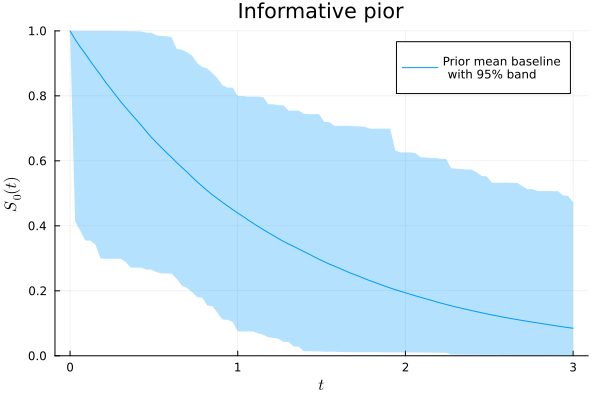

In [12]:
# Prior inspection
# Plotting time grid
t =  collect(LinRange(0.0,3.0,100))
# Plot
prior_band = prior_credible_band(0.05,3000,t,5.0,baseline)
prior_plot = plot( prior_band, fillalpha=0.3, xlabel="\$t\$", ylabel="\$S_0(t)\$", label="Prior mean baseline \n with 95% band",  title="Informative pior", size=(600,400))

# Regression

In [13]:
# Create covariate array.
z_keys = [:age,:sex,:wt_loss]
lung_Z = [ [ lung[j,i] for i in z_keys] for j in 1:nrow(lung)]
first(lung_Z,7)

7-element Vector{Vector{Float64}}:
 [0.68, 1.0, 0.5079365079365079]
 [0.56, 1.0, 0.5079365079365079]
 [0.57, 1.0, 0.25396825396825395]
 [0.6, 1.0, -0.4444444444444444]
 [0.74, 1.0, -0.4444444444444444]
 [0.68, 2.0, 0.19047619047619047]
 [0.71, 2.0, -0.38095238095238093]

In [14]:
# Median quantities for later assesment of fits
med_age = median([v[1] for v in lung_Z])
med_age_m = median([v[1] for v in lung_Z[lung.sex .== 1.0] ])
med_age_f = median([v[1] for v in lung_Z[lung.sex .== 2.0] ])
med_wt_loss_m = median([v[3] for v in lung_Z[lung.sex .== 1.0] ])
med_wt_loss_f = median([v[3] for v in lung_Z[lung.sex .== 2.0] ]);

In [15]:
# Data struct for NTR modelling
lung_dataregre = RegressionSurvivalData( lung_T, lung_δ, lung_Z)

Right-censored survival data with covariates
  Observations:       214
  Exact events:       152 (71.0%)
  Right-censored:     62 (29.0%)
  Covariates:         3
  Distinct times:     179 (83.6%)
  Distinct covariates:197 (92.1%)

In [16]:
# Compilation runs
NTRsurv.loglikelihood([0.3,0.0,-0.3],α,baseline,lung_dataregre) # In this notebbok loglikelihood funcion is also loaded by Survival so it has to be sepcified.
robbins_monro_mh_within_gibbs_tune(3,3,x->NTRsurv.loglikelihood(x,α,baseline,lung_dataregre),[1.0,1.0,1.0],[1.0,1.0,1.0],[0.4,0.4,0.4],0.7)

([[1.0, 1.0, 1.0], [1.0634913484723583, 1.0634913484723583, 1.0634913484723583], [1.113940274312152, 0.8835317934793192, 0.8835317934793192], [1.3983053111119192, 0.7592686142773132, 0.9176537961413386]], [0.07398730804021936, 0.09792179747747298, 0.10364619448679838], -672.1011862612232)

In [17]:
# Robbins-Monro algorithm for variance of proposal distribution tuning
sd_prop_tuned, s₀_tune, lliks₀_tune = robbins_monro_mh_within_gibbs_tune(150,100,x->NTRsurv.loglikelihood(x,α,baseline,lung_dataregre) + logpdf(Normal(0,5),x[1]) + logpdf(Normal(0,5),x[2]) + logpdf(Normal(0,5),x[3]),[1.0,1.0,1.0],[1.0,1.0,1.0],[0.4,0.4,0.4],0.7; show_progress=false)

([[1.0, 1.0, 1.0], [1.1494470310131113, 0.8797752848920806, 0.8635163340914853], [1.2646336335702275, 0.813995249091458, 0.7588506083346901], [1.3210365945244482, 0.7551634490151008, 0.6880208987954454], [1.3712749668738677, 0.7294050814998818, 0.6244724561818908], [1.4293765796986608, 0.6933328161501031, 0.590178233155632], [1.4382788956064105, 0.6763258269568754, 0.5466722391622757], [1.477434633500991, 0.664322854979293, 0.5433335758600838], [1.4883738218422764, 0.6506288529226217, 0.5241127412943085], [1.5198998744334786, 0.6420316570136608, 0.5058476243440387]  …  [1.884405359574196, 0.46935391504625434, 0.2782280008285561], [1.8852314491114854, 0.4694126933715133, 0.2783499709977119], [1.8842919692292632, 0.4688865248348525, 0.2780379662330612], [1.8915498888647762, 0.4696721806128953, 0.27807244869199255], [1.8888671075275356, 0.4698751051116381, 0.27733556634958867], [1.8879393011067407, 0.4692118566585267, 0.277114232299823], [1.8899020927840153, 0.46955614404253987, 0.2769787

In [18]:
# Metropolis-Hastings within Gibbs chain run
chain_s, _ =  random_walk_mh_within_gibbs( 3000, x-> NTRsurv.loglikelihood(x,α,baseline,lung_dataregre) + logpdf(Normal(0,5),x[1]) + logpdf(Normal(0,5),x[2]) + logpdf(Normal(0,5),x[3]), s₀_tune, lliks₀_tune, sd_prop_tuned[end])

([[1.0840939744168328, -0.3093720956520127, -0.05666813861094706], [1.3089008473023696, -0.3093720956520127, -0.05666813861094706], [0.06941042691136978, -0.5747056928082139, -0.10583533109667576], [0.06941042691136978, -0.5602843989559864, -0.10583533109667576], [-0.0518411499666451, -0.310715066273879, -0.08892017100800265], [-0.0518411499666451, -0.310715066273879, -0.08892017100800265], [1.2623379673287694, -0.310715066273879, -0.08892017100800265], [1.2623379673287694, -0.41024904373910587, -0.08892017100800265], [0.6166021702391109, -0.41024904373910587, -0.08892017100800265], [0.6166021702391109, -0.6703440048482924, -0.08892017100800265]  …  [1.6003660443748902, -0.6282103346974411, -0.016802636767421927], [1.6003660443748902, -0.6282103346974411, -0.016802636767421927], [1.6003660443748902, -0.817332882821517, 0.022549715356419323], [1.6003660443748902, -0.817332882821517, 0.022549715356419323], [1.6003660443748902, -0.817332882821517, 0.022549715356419323], [1.600366044374890

In [19]:
# Acceptance rates in the MH within Gibbs chains, target values were 0.4
acceptance_rate(chain_s)

3-element Vector{Float64}:
 0.40346782260753583
 0.3901300433477826
 0.39813271090363456

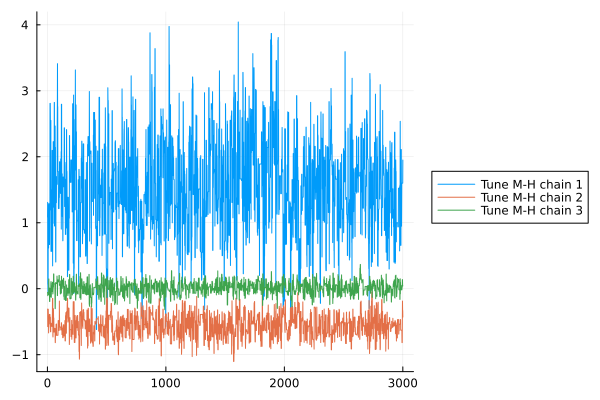

In [20]:
# Plot MH within Gibbs chains
plot([ v[1] for v in chain_s],label="Tune M-H chain 1",legend=:outerright)
plot!([ v[2] for v in chain_s],label="Tune M-H chain 2")
plot!([ v[3] for v in chain_s],label="Tune M-H chain 3")

In [21]:
# Posterior mean estimate of regression coefficients for plug-in NTR-Cox model
c_post = mean(chain_s)

3-element Vector{Float64}:
  1.5526352284851233
 -0.5577682842427224
  0.013013495922569902

In [22]:
# Plug-in Cox-NTR model for regression
plugin_cox_model = PluginCoxNeutralToTheRightModel( c_post, α, baseline, lung_dataregre)

Plugin Cox Neutral-to-the-right model
  Coefficients:       ["1.5526", "-0.55777", "0.013013"]
  Risk score:         Cox
  α:                  1.0
  Center at Z=zeros:  Empirical ExponentialBaseline(rate=0.82555)
  Data:               SurvivalData(obs.=214, exact=152, censored=62, distinct T = 179, distinct Z = 197)

In [23]:
# We will compute posterior survival bands for covariates
z_new_1 = [med_age_m,1.0,med_wt_loss_m]
z_new_2 = [med_age_f,2.0,med_wt_loss_f]
zv = [z_new_1,z_new_2]

2-element Vector{Vector{Float64}}:
 [0.64, 1.0, 0.06349206349206349]
 [0.61, 2.0, -0.19047619047619047]

In [24]:
# NTR posterior credible bands computation
plugin_NTR_bands = posterior_credible_band(0.05,3000,t, zv, plugin_cox_model)

2-element Vector{NTRsurv.CredibleBand}:
 CredibleBand( level=0.05, estimate=posterior mean, covariate Z=[0.64, 1.0, 0.063492], model=plugin Bayesian, draws=3000)
 CredibleBand( level=0.05, estimate=posterior mean, covariate Z=[0.61, 2.0, -0.19048], model=plugin Bayesian, draws=3000)

In [25]:
# Plugin NTR model credible band for covariate zv[1]
plugin_NTR_bands[1]

Credible band
  Credible level:     95.0%
  Estimate:           posterior mean
  Covariate:          Z=[0.64, 1.0, 0.063492]
  Model:              Plugin Bayesian
  Time grid:          0.0 to 3.0 (100 points)
  Monte-Carlo paths:  3000
  Median band width:  0.16945
  Maximum band width: 0.19734

In [26]:
# Cox-NTR model fit using the full Markov chain
cox_model = CoxNeutralToTheRightModel(chain_s, α, baseline, lung_dataregre)

Cox Neutral-to-the-right model
  Coefficient draws:  3000
  Risk score:         Cox
  Gamma process α:    1.0
  Center at Z=zeros:  Empirical ExponentialBaseline(rate=0.82555)
  Data:               SurvivalData(obs.=214, exact=152, censored=62, distinct T = 179, distinct Z = 197)

In [27]:
# Fully Bayes NTR posterior credible bands computation
NTR_bands = posterior_credible_band(0.05, t, zv, cox_model)

2-element Vector{NTRsurv.CredibleBand}:
 CredibleBand( level=0.05, estimate=posterior mean, covariate Z=[0.64, 1.0, 0.063492], model=fully Bayesian, draws=3000)
 CredibleBand( level=0.05, estimate=posterior mean, covariate Z=[0.61, 2.0, -0.19048], model=fully Bayesian, draws=3000)

In [28]:
# NTR model credible band for covariate zv[1]
NTR_bands[1]

Credible band
  Credible level:     95.0%
  Estimate:           posterior mean
  Covariate:          Z=[0.64, 1.0, 0.063492]
  Model:              Fully Bayesian
  Time grid:          0.0 to 3.0 (100 points)
  Monte-Carlo paths:  3000
  Median band width:  0.18952
  Maximum band width: 0.21713

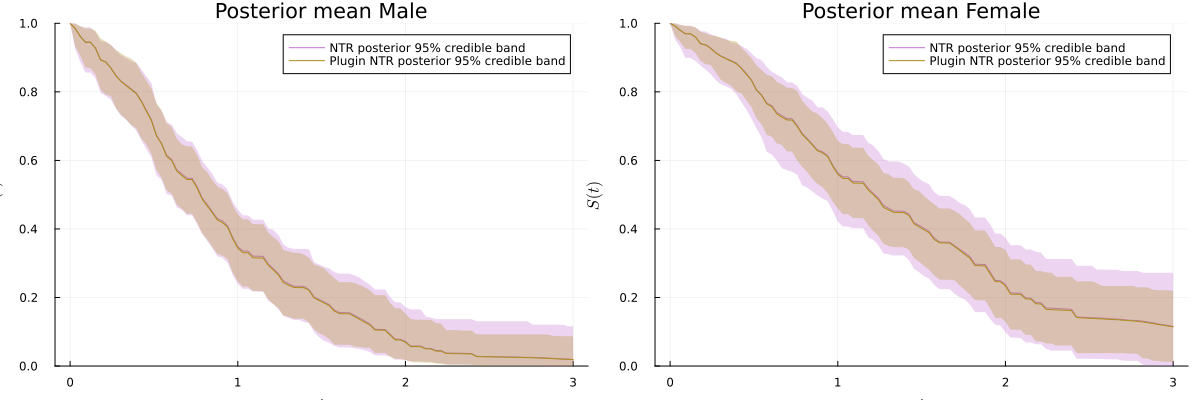

In [29]:
# Plot for fully-Bayes NTR-Cox comparisson with plugin NTR-Cox survival band fits for
# Male population sub-plot
Comp_plotM =  plot( NTR_bands[1], c=4, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="NTR posterior 95% credible band",size=(600,400) , title="Male")
plot!( plugin_NTR_bands[1], c=5, fillalpha=0.3,  label="Plugin NTR posterior 95% credible band", title = "Posterior mean Male")
# Female population sub-plot
Comp_plotF = plot( NTR_bands[2], c=4, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="NTR posterior 95% credible band",size=(600,400),title="Female")
plot!( plugin_NTR_bands[2], c=5, fillalpha=0.3,  label="Plugin NTR posterior 95% credible band", title="Posterior mean Female")
# Comparisson plot
plot( Comp_plotM, Comp_plotF, size=(1200,400))

We observe that there is uncertainty in the regression coefficients as the plug-in Cox-NTR model differs from the fully Bayesian Cox-NTR model, specially in the female median covariate fits.

Now we compare with frequentist uncertainty quantification.

In [30]:
# DataFrame for frequentist Cox fits with Survival.jl
df = DataFrame( time = lung_dataregre.Tr, status = lung_dataregre.δr, age = [ z[1] for z in lung_Z ], sex = [ z[2] for z in lung_Z ], wt_loss = [ z[3] for z in lung_Z ]  )
first(df,7)

Row,time,status,age,sex,wt_loss
,Float64,Int64,Float64,Float64,Float64
1,0.0136986,1,0.68,1.0,0.507937
2,0.030137,1,0.56,1.0,0.507937
3,0.030137,1,0.57,1.0,0.253968
4,0.0328767,1,0.6,1.0,-0.444444
5,0.0356164,1,0.74,1.0,-0.444444
6,0.0356164,1,0.68,2.0,0.190476
7,0.0410959,1,0.71,2.0,-0.380952


In [31]:
# Add EvenTime column to DataFrame
df.event = EventTime.( df.time, df.status)
last(df.event,7)

7-element Vector{EventTime{Float64}}:
 2.23013698630137
 2.249315068493151+
 2.3013698630136985+
 2.419178082191781
 2.643835616438356+
 2.767123287671233+
 2.8+

In [32]:
# Fit fequentist Cox model
freq_cox_model = Survival.coxph(@formula(event ~ age + sex + wt_loss), df)

StatsModels.TableRegressionModel{CoxModel{Float64}, Matrix{Float64}}

event ~ age + sex + wt_loss

Coefficients:
───────────────────────────────────────────────────
           Estimate  Std.Error    z value  Pr(>|z|)
───────────────────────────────────────────────────
age       0.475442    0.879301   0.540705    0.5887
sex      -0.228572    0.170114  -1.34364     0.1791
wt_loss   0.0784485   0.106895   0.733881    0.4630
───────────────────────────────────────────────────

In [33]:
# Frequentist survival curves estimators
c_freq =  coef(freq_cox_model)
κBreslow, t_Breslow = BreslowEstimCoxModel_with_time(freq_cox_model)
Sfreq1 = exp.( - exp( dot(c_freq,zv[1]) )  .* κBreslow )
Sfreq2 = exp.( - exp( dot(c_freq,zv[2]) )  .* κBreslow );

In [34]:
# Computation of asymptotic frequentist confidence bands
freq_bands = freq_confidence_bands( 0.05, 3000, t, zv, lung_dataregre, freq_cox_model);

In [35]:
# Computation of bootstrapped frequentist bands
boot_bands = bootstrap_confidence_band( 0.05, 3000, t, zv, df, z_keys);

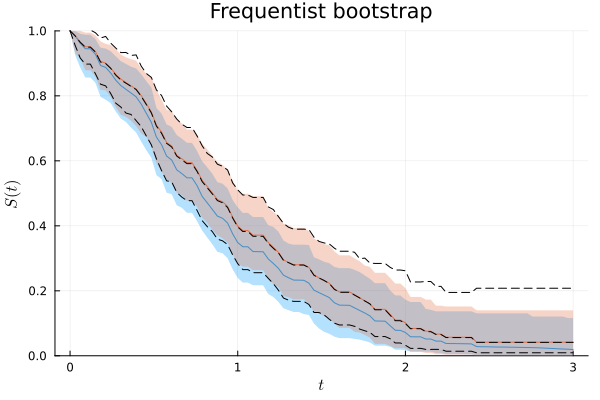

In [36]:
# Plot comparisson of fully Bayesian and frequentist bands for male median covariate.
Mplot = plot( NTR_bands[1], xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="NTR posterior 95% credible band",title="Male",size=(600,400))
plot!( boot_bands[1], fillalpha=0.3,  label="Bootstrap frequentist 95% confidence band")
plot!(t, freq_bands[1].d,  c=:black, linestyle=:dash,  label="Asymptotic frequentist 95% confidence band")
plot!(t, freq_bands[1].u,  c=:black, linestyle=:dash,  label="")
plot!(t, freq_bands[1].m,  c=:black, linestyle=:dash,  label="",legend=false)

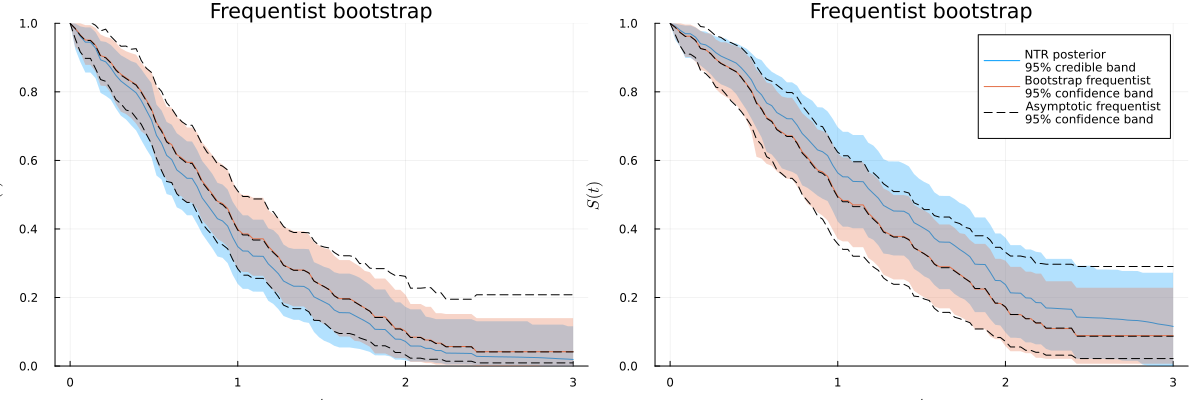

In [37]:
# Plot comparisson of fully Bayesian and frequentist bands for female median covariate.
Fplot = plot( NTR_bands[2], xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="NTR posterior \n95% credible band",title="Female",size=(600,400))
plot!( boot_bands[2], fillalpha=0.3,  label="Bootstrap frequentist \n95% confidence band")
plot!(t, freq_bands[2].d,  c=:black, linestyle=:dash,  label="Asymptotic frequentist \n95% confidence band")
plot!(t, freq_bands[2].u,  c=:black, linestyle=:dash,  label="")
plot!(t, freq_bands[2].m,  c=:black, linestyle=:dash,  label="")
plot( Mplot, Fplot, size=(1200,400))

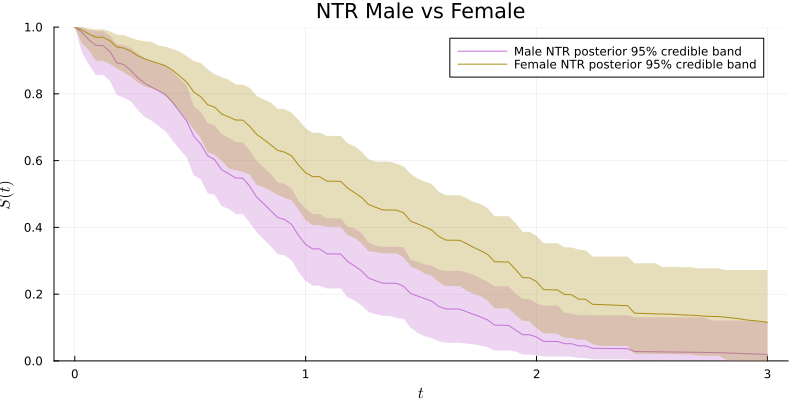

In [38]:
# Plot comparisson of male and female median covariate survival fits with NTR model.
plot( NTR_bands[1], c=4, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="Male NTR posterior 95% credible band ", title="Cox-NTR model", size=(600,400))
plot!( NTR_bands[2], c=5, fillalpha=0.3,  label="Female NTR posterior 95% credible band", title="NTR Male vs Female", size=(800,400))

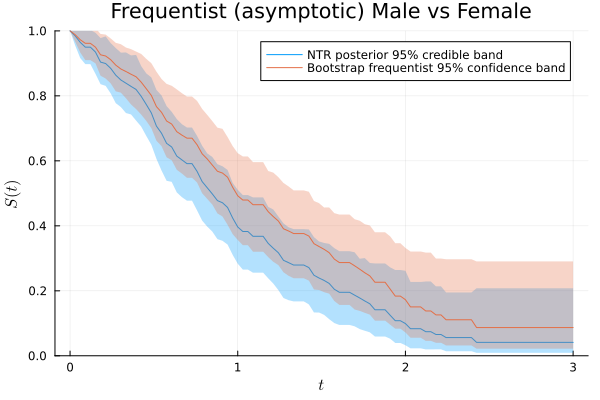

In [39]:
# Plot comparisson of male and female median covariate survival fits with frequentist Cox model (Breslow estimators) \nand asymptotic distribution uncertianty quantification
plot( freq_bands[1], fillalpha=0.3, label="NTR posterior 95% credible band",size=(600,400))
plot!( freq_bands[2],  label="Bootstrap frequentist 95% confidence band", title="Frequentist (asymptotic) Male vs Female",)

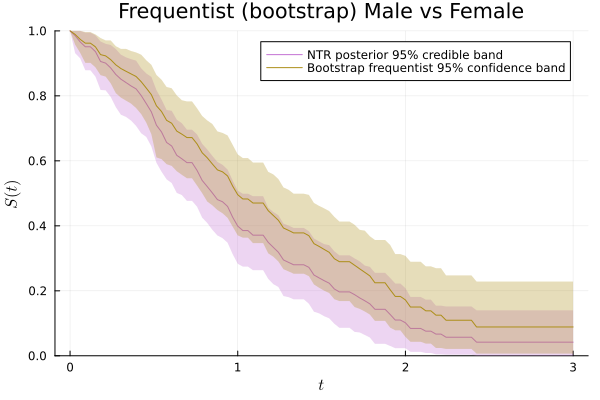

In [40]:
# Plot comparisson of male and female median covariate survival fits with frequentist Cox model (Breslow estimators) \nand bootstrap uncertianty quantification
plot( boot_bands[1], c=4, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3,label="NTR posterior 95% credible band",size=(600,400))
plot!( boot_bands[2], c=5, fillalpha=0.3,  label="Bootstrap frequentist 95% confidence band", title="Frequentist (bootstrap) Male vs Female")

We observe that the fully Bayesian Cox-NTR and frequentist Cox-Breslow analyses produce survival bands of broadly comparable width for the representative covariate profiles. The asymptotic and bootstrap Cox procedures agree closely with each other, however they do not overlap signalling a finite data regime also pointed out by their difference with the Bayesian Cox-NTR model in view of the Bernstein-von Mises theorem as discussed in the Weibulls simulation study tutorial.

We compute restricted mean survival times (RMST) up to time $3$ as

$$
\Delta_3
=
\int_0^3
\left\{
S(t\mid\pmb z_{\mathrm F})
-
S(t\mid\pmb z_{\mathrm M})
\right\}
\,\mathrm{d}t,
$$
in order to evaluate differences between the fitted models and perform a sensitivity analysis of the fully Bayesian Cox-NTR model.

In [41]:
plugin_rmst_1 = RestrictedMeanSurvivalTime( 3000, t, z_new_1, plugin_cox_model )

Restricted mean survival time
  Restriction time:   3.0
  Covariate:          [0.64, 1.0, 0.063492]
  Model:              Plugin Cox Neutral-to-the-right-model
  Draws:              100.0
  Mean:               0.91878
  Credible interval:  [0.82503, 1.0231]
  Level:              95.0%

In [42]:
rmst_1 = RestrictedMeanSurvivalTime( t, z_new_1, cox_model )

Restricted mean survival time
  Restriction time:   3.0
  Covariate:          [0.64, 1.0, 0.063492]
  Model:              Cox Neutral-to-the-right-model
  Draws:              100.0
  Mean:               0.92754
  Credible interval:  [0.80846, 1.0624]
  Level:              95.0%

In [43]:
plugin_rmst_contrast =  RestrictedMeanSurvivalTimeContrast(3000,t,z_new_1,z_new_2,plugin_cox_model)

Restricted mean survival time contrast
  Restriction time:   3.0
  Model:              Plugin Cox Neutral-to-the-right-model
  Draws:              100.0
  Mean:               0.44352
  Credible interval:  [0.39679, 0.49003]
  Level:              0.05

In [44]:
rmst_contrast =  RestrictedMeanSurvivalTimeContrast(t,z_new_1,z_new_2,cox_model)

Restricted mean survival time contrast
  Restriction time:   3.0
  Model:              Cox Neutral-to-the-right-model
  Draws:              100.0
  Mean:               0.44653
  Credible interval:  [0.18492, 0.71125]
  Level:              0.05

In [45]:
freq_rmst_contrast = frequentist_rmst(3000,t,z_new_1,z_new_2,lung_dataregre,freq_cox_model)

Restricted mean survival time contrast
  Restriction time:   3.0
  Model:              Frequentist
  Draws:              100.0
  Mean:               0.19484
  Credible interval:  [-0.050951, 0.47078]
  Level:              0.05

In [46]:
freq_boot_rmst_contrast = bootstrap_rmst(3000,t,z_new_1,z_new_2,df, z_keys)

Restricted mean survival time contrast
  Restriction time:   3.0
  Model:              Frequentist bootstrap
  Draws:              100.0
  Mean:               0.19554
  Credible interval:  [-0.043081, 0.44334]
  Level:              0.05

In [47]:
# RMST table
# Auxilliary function for RMST differences between models data frame
function rmst_difference_summary(method::String, Δ::Vector{Float64})
    q = quantile(Δ, [0.025, 0.50, 0.975])
    return (
        method = method,
        mean = mean(Δ),
        standard_deviation = std(Δ),
        median = q[2],
        lower_95 = q[1],
        upper_95 = q[3],
        interval_width = q[3] - q[1],
        fraction_positive = mean(Δ .> 0.0)
    )
end
# RMST table computation
rmst_summary = DataFrame([
    rmst_difference_summary(
        "Cox-NTR",
        rmst_contrast.v
    ),
    rmst_difference_summary(
        "Asymptotic Cox-Breslow",
        freq_rmst_contrast.v
    ),
    rmst_difference_summary(
        "Bootstrap Cox-Breslow",
        freq_boot_rmst_contrast.v
    )
])
show(stdout, MIME("text/html"), rmst_summary, eltypes=false)

Row,method,mean,standard_deviation,median,lower_95,upper_95,interval_width,fraction_positive
1,Cox-NTR,0.446532,0.137441,0.442518,0.184923,0.711246,0.526323,0.999667
2,Asymptotic Cox-Breslow,0.194838,0.132247,0.186863,-0.0509512,0.470781,0.521732,0.942
3,Bootstrap Cox-Breslow,0.195538,0.122261,0.195231,-0.0430808,0.443336,0.486417,0.946667


We observe that the principal difference between the Bayesian and frequentist analyses is not the dispersion of the three-year RMST, but its center. For the representative female-minus-male profile contrast, the fully Bayesian Cox-NTR posterior is centered at a larger positive value than the asymptotic and bootstrap Cox-Breslow distributions. Its posterior standard deviation is nevertheless almost identical to that of the asymptotic Cox approximation. Under the fully Bayesian Cox-NTR model, the 95% credible interval for the contrast excludes zero and the posterior probability that $\Delta_3>0$ is approximately $0.998$. By comparison, the asymptotic and bootstrap Cox-Breslow 95% confidence intervals include zero.

In [48]:
# Cox-NTR model parameters for sensitivity analysis
α_vec = [ 1.0, 5.0 ] 
σ_vec = [ 5.0, 10.0 ] 
λ_vec = [ 0.1, 1.0, 10.0 ]

3-element Vector{Float64}:
  0.1
  1.0
 10.0

In [49]:
# RMST based sensitivity analysis for fullly Bayes Cox-NTR models
function NTRsensitivity_analysis(α_vec::Vector{Float64},σ_vec::Vector{Float64},λ_vec::Vector{Float64},
    t::Vector{Float64},z_news::Vector{Vector{Float64}})
    alphas = zeros(12)
    lambdas = zeros(12)
    sigmas = zeros(12)
    acc_rates = zeros(12)
    Δ_means = zeros(12)
    Δ_sdevs = zeros(12)
    Δ_lowers95percint = zeros(12)
    Δ_uppers95percint = zeros(12)
    Δ_medians = zeros(12)
    Δ_95percint_lengths = zeros(12)
    Δ_probgeqzeros = zeros(12)
    i_tmp = 1
    for α in α_vec, σ in σ_vec, λ in λ_vec
        alphas[i_tmp] = α
        lambdas[i_tmp] = λ
        sigmas[i_tmp] = σ
        baseline_tmp = ExponentialBaseline(λ)
        sd_prop_tuned_tmp, s₀_tune_tmp, lliks₀_tune_tmp = robbins_monro_mh_within_gibbs_tune(150,100,x->NTRsurv.loglikelihood(x,α,baseline_tmp,lung_dataregre) + logpdf(Normal(0,σ),x[1]) + logpdf(Normal(0,σ),x[2]) + logpdf(Normal(0,σ),x[3]),[1.0,1.0,1.0],[1.0,1.0,1.0],[0.4,0.4,0.4],0.7)
        chain_s_tmp, _ =  random_walk_mh_within_gibbs( 3000, x-> NTRsurv.loglikelihood(x,α,baseline_tmp,lung_dataregre) + logpdf(Normal(0,σ),x[1]) + logpdf(Normal(0,σ),x[2]) + logpdf(Normal(0,σ),x[3]), s₀_tune_tmp, lliks₀_tune_tmp, sd_prop_tuned_tmp[end])
        acc_rates[i_tmp] = mean( acceptance_rate(chain_s) )
        cox_model_tmp = CoxNeutralToTheRightModel(chain_s, α, baseline, lung_dataregre)
        Sdraws_tmp = sample_posterior_survival(t, z_news, cox_model_tmp)
        Δ_tmp = NTRsurv.rmst_comp(t, Sdraws_tmp[2] .- Sdraws_tmp[1])
        Δ_means[i_tmp] = mean(Δ_tmp)
        Δ_sdevs[i_tmp] = std(Δ_tmp)
        q_tmp = quantile(Δ_tmp,[0.025,0.5,0.975])
        Δ_lowers95percint[i_tmp] = q_tmp[1]
        Δ_uppers95percint[i_tmp] = q_tmp[3]
        Δ_medians[i_tmp] = q_tmp[2]
        Δ_95percint_lengths[i_tmp] = q_tmp[3]-q_tmp[1]
        Δ_probgeqzeros[i_tmp] = mean( Δ_tmp .> 0.0 )
        i_tmp += 1
    end
    return alphas, lambdas, sigmas, acc_rates, Δ_means, Δ_sdevs, Δ_lowers95percint, Δ_uppers95percint, Δ_medians, Δ_95percint_lengths, Δ_probgeqzeros
end

NTRsensitivity_analysis (generic function with 1 method)

In [50]:
# Sensitivity analysis
alphas, lambdas, sigmas, sens_acc_rates, sens_Δ_means, sens_Δ_sdevs, sens_Δ_lower95percints, sens_Δ_upper95percints, sens_Δ_medians, sens_Δ_95percint_lengths, sens_Δ_probgeqzeros = NTRsensitivity_analysis(α_vec,σ_vec,λ_vec,t,zv)

Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:13
Progress: 100%[==================================================] Time: 0:00:13
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12
Progress: 100%[==================================================] Time: 0:00:12


([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0], [0.1, 1.0, 10.0, 0.1, 1.0, 10.0, 0.1, 1.0, 10.0, 0.1, 1.0, 10.0], [5.0, 5.0, 5.0, 10.0, 10.0, 10.0, 5.0, 5.0, 5.0, 10.0, 10.0, 10.0], [0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651, 0.397243525619651], [0.44595315231559624, 0.4464696354127242, 0.4466810546219416, 0.4451931001795849, 0.4464685706555938, 0.4463086154944658, 0.4521718182829333, 0.4520435478774692, 0.4520647551777248, 0.4521506574344533, 0.452450794854433, 0.4520059716689077], [0.13598444436139612, 0.13671963208624538, 0.1374162303710741, 0.13661816012045028, 0.13710067913867482, 0.1368939255481811, 0.1396884346978467, 0.13975437809910682, 0.1391240277114901, 0.13980448274465626, 0.14023933840719008, 0.13986065086826294], [0.18545323494316798, 0.1813530553182766, 0.18051413086184864, 0.1782751370871530

In [51]:
# Sensitivity analysis data frame
sensdf = DataFrame( alpha = alphas, lambda=lambdas, sigma = sigmas, Acc_rates =  sens_acc_rates, Δ_mean = round.(sens_Δ_means; digits = 3), 
    Δ_stdev = round.(sens_Δ_sdevs; digits = 3), Δ_95percCIlower = round.( sens_Δ_lower95percints; digits=3), 
    Δ_95percCIupper = round.( sens_Δ_upper95percints; digits=3), Δ_median = round.( sens_Δ_medians; digits=3),
    Δ_probgeqzero = sens_Δ_probgeqzeros )
show(stdout, MIME("text/html"), sensdf, eltypes=false)

Row,alpha,lambda,sigma,Acc_rates,Δ_mean,Δ_stdev,Δ_95percCIlower,Δ_95percCIupper,Δ_median,Δ_probgeqzero
1,1.0,0.1,5.0,0.397244,0.446,0.136,0.185,0.706,0.445,0.999667
2,1.0,1.0,5.0,0.397244,0.446,0.137,0.181,0.71,0.444,0.999667
3,1.0,10.0,5.0,0.397244,0.447,0.137,0.181,0.708,0.444,0.999667
4,1.0,0.1,10.0,0.397244,0.445,0.137,0.178,0.714,0.442,0.999667
5,1.0,1.0,10.0,0.397244,0.446,0.137,0.184,0.711,0.443,0.999667
6,1.0,10.0,10.0,0.397244,0.446,0.137,0.186,0.717,0.445,0.999667
7,5.0,0.1,5.0,0.397244,0.452,0.14,0.184,0.721,0.447,0.999667
8,5.0,1.0,5.0,0.397244,0.452,0.14,0.185,0.73,0.45,0.999667
9,5.0,10.0,5.0,0.397244,0.452,0.139,0.184,0.721,0.451,0.999667
10,5.0,0.1,10.0,0.397244,0.452,0.14,0.186,0.717,0.449,0.999667


Sensitivity analyses using alternative baseline and coefficient-prior specifications produced qualitatively similar Cox-NTR conclusion that the posterior distribution of the three-year RMST contrast is concentrated primarily on positive values. However there is moderate sensitivity in the estimated magnitudes.